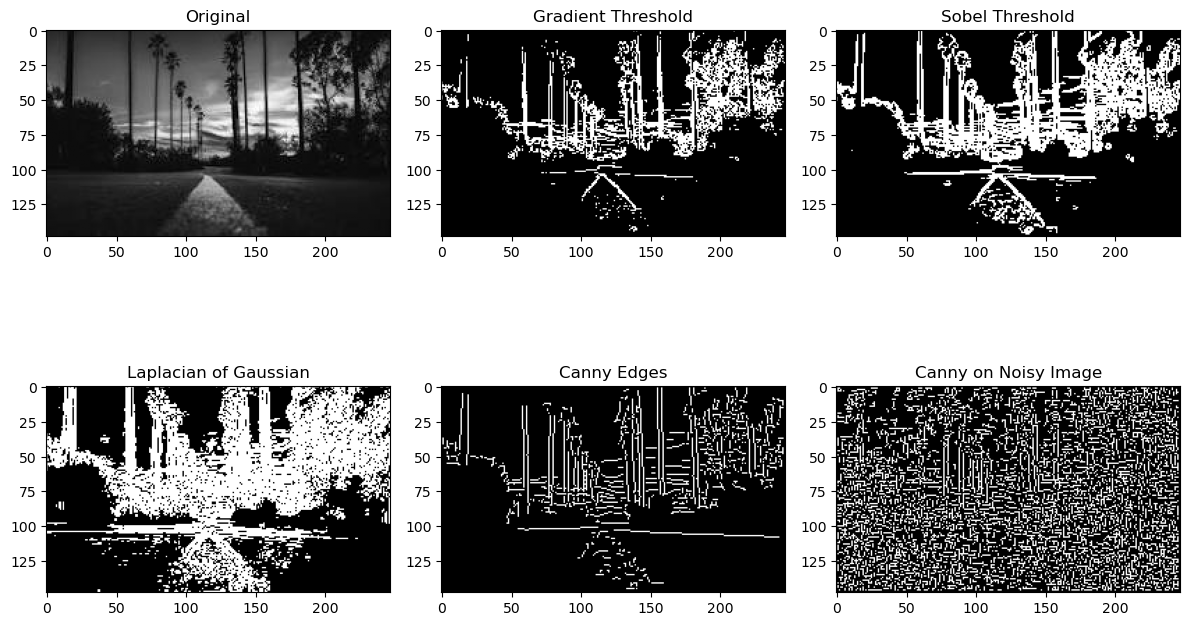

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import convolve, gaussian_filter

# -------------------------------
# Helper Functions
# -------------------------------

# 1. Simple Gradient Magnitude Thresholding
def gradient_threshold(img, thresh=50):
    # Convert image to float
    img = img.astype(np.float32)
    
    # Compute gradients using simple finite differences
    Gx = np.zeros_like(img)
    Gy = np.zeros_like(img)
    
    Gx[:, :-1] = np.diff(img, axis=1)
    Gy[:-1, :] = np.diff(img, axis=0)
    
    # Gradient magnitude
    G = np.hypot(Gx, Gy)
    
    # Apply threshold
    edges = np.zeros_like(G)
    edges[G > thresh] = 255
    return edges

# 2. Sobel Operator with Thresholding
def sobel_edges(img, thresh=100):
    Kx = np.array([[-1,0,1],[-2,0,2],[-1,0,1]])
    Ky = np.array([[-1,-2,-1],[0,0,0],[1,2,1]])
    
    Gx = convolve(img.astype(np.float32), Kx, mode='reflect')
    Gy = convolve(img.astype(np.float32), Ky, mode='reflect')
    
    G = np.hypot(Gx, Gy)
    
    edges = np.zeros_like(G)
    edges[G > thresh] = 255
    return edges

# 3. Laplacian of Gaussian (LoG)
def log_edges(img, sigma=1.0, thresh=0):
    # Smooth image with Gaussian
    smoothed = gaussian_filter(img.astype(np.float32), sigma=sigma)
    
    # Laplacian
    lap = cv2.Laplacian(smoothed, cv2.CV_32F, ksize=3)
    
    # Zero-crossings detection
    edges = np.zeros_like(lap, dtype=np.uint8)
    # Simple threshold on absolute Laplacian
    edges[np.abs(lap) > thresh] = 255
    return edges

# 4. Canny Edge Detector (reuse previous implementation)
def canny_edges(img, kernel_size=5, sigma=1, low_ratio=0.05, high_ratio=0.15):
    smoothed = gaussian_filter(img.astype(np.float32), sigma)
    
    # Gradient
    Kx = np.array([[-1,0,1],[-2,0,2],[-1,0,1]])
    Ky = np.array([[-1,-2,-1],[0,0,0],[1,2,1]])
    Ix = convolve(smoothed, Kx, mode='reflect')
    Iy = convolve(smoothed, Ky, mode='reflect')
    
    G = np.hypot(Ix, Iy)
    theta = np.arctan2(Iy, Ix)
    
    # Non-Max Suppression
    def nms(G, theta):
        M, N = G.shape
        Z = np.zeros((M,N), dtype=np.float32)
        angle = theta * 180. / np.pi
        angle[angle < 0] += 180
        for i in range(1,M-1):
            for j in range(1,N-1):
                q = 255
                r = 255
                if (0 <= angle[i,j] < 22.5) or (157.5 <= angle[i,j] <= 180):
                    q = G[i, j+1]; r = G[i, j-1]
                elif (22.5 <= angle[i,j] < 67.5):
                    q = G[i+1, j-1]; r = G[i-1, j+1]
                elif (67.5 <= angle[i,j] < 112.5):
                    q = G[i+1, j]; r = G[i-1, j]
                elif (112.5 <= angle[i,j] < 157.5):
                    q = G[i-1, j-1]; r = G[i+1, j+1]
                if (G[i,j] >= q) and (G[i,j] >= r):
                    Z[i,j] = G[i,j]
        return Z

    nms_img = nms(G, theta)
    
    # Hysteresis
    high = nms_img.max() * high_ratio
    low = high * low_ratio
    M, N = nms_img.shape
    res = np.zeros((M,N), dtype=np.int32)
    strong, weak = 255, 75
    strong_i, strong_j = np.where(nms_img >= high)
    weak_i, weak_j = np.where((nms_img <= high) & (nms_img >= low))
    res[strong_i, strong_j] = strong
    res[weak_i, weak_j] = weak
    # Edge tracking
    for i in range(1,M-1):
        for j in range(1,N-1):
            if res[i,j] == weak:
                if ((res[i+1, j-1] == strong) or (res[i+1, j] == strong) or (res[i+1, j+1] == strong)
                    or (res[i, j-1] == strong) or (res[i, j+1] == strong)
                    or (res[i-1, j-1] == strong) or (res[i-1, j] == strong) or (res[i-1, j+1] == strong)):
                    res[i,j] = strong
                else:
                    res[i,j] = 0
    return res

# -------------------------------
# Load Image
# -------------------------------
img = cv2.imread("image2.jpeg", 0)
if img is None:
    raise ValueError("Image not found. Check the file path.")

# -------------------------------
# Apply Edge Detectors
# -------------------------------
edges_grad = gradient_threshold(img, thresh=30)
edges_sobel = sobel_edges(img, thresh=100)
edges_log = log_edges(img, sigma=1.0, thresh=10)
edges_canny = canny_edges(img, kernel_size=5, sigma=1, low_ratio=0.05, high_ratio=0.15)

# -------------------------------
# Add Gaussian Noise & Test Robustness
# -------------------------------
noise_img = img + np.random.normal(0, 25, img.shape).astype(np.uint8)
edges_sobel_noise = sobel_edges(noise_img, thresh=100)
edges_canny_noise = canny_edges(noise_img, kernel_size=5, sigma=1, low_ratio=0.05, high_ratio=0.15)

# -------------------------------
# Visualization
# -------------------------------
plt.figure(figsize=(12,8))

plt.subplot(2,3,1); plt.imshow(img, cmap='gray'); plt.title("Original")
plt.subplot(2,3,2); plt.imshow(edges_grad, cmap='gray'); plt.title("Gradient Threshold")
plt.subplot(2,3,3); plt.imshow(edges_sobel, cmap='gray'); plt.title("Sobel Threshold")
plt.subplot(2,3,4); plt.imshow(edges_log, cmap='gray'); plt.title("Laplacian of Gaussian")
plt.subplot(2,3,5); plt.imshow(edges_canny, cmap='gray'); plt.title("Canny Edges")
plt.subplot(2,3,6); plt.imshow(edges_canny_noise, cmap='gray'); plt.title("Canny on Noisy Image")

plt.tight_layout()
plt.show()
